# Robustness and Failure Case Analysis


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import importlib, src.utils
importlib.reload(src.utils)
from src.utils import load_results_csv, DETECTOR_COLORS

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130})

RESULTS_DIR = Path('results/performance')
ALGOS = ['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
METRIC = 'auc_roc'

all_results = load_results_csv('results/performance')
print(f'Loaded {len(all_results)} datasets.')


Loaded 12 datasets.


## Dataset Characteristics

In [2]:
dataset_meta = pd.DataFrame([
    {'dataset': 'arrhythmia', 'n_samples': 452, 'n_features': 274, 'type': 'tabular'},
    {'dataset': 'cardio', 'n_samples': 1831, 'n_features': 21, 'type': 'tabular'},
    {'dataset': 'mammography', 'n_samples': 11183, 'n_features': 6, 'type': 'tabular'},
    {'dataset': 'satellite', 'n_samples': 6435, 'n_features': 36, 'type': 'tabular'},
    {'dataset': 'shuttle', 'n_samples': 49097, 'n_features': 9, 'type': 'tabular'},
    {'dataset': 'breastw', 'n_samples': 683, 'n_features': 9, 'type': 'tabular'},
    {'dataset': 'fcps_target', 'n_samples': 770, 'n_features': 2, 'type': 'geometric'},
    {'dataset': 'sipu_flame', 'n_samples': 240, 'n_features': 2, 'type': 'geometric'},
    {'dataset': 'graves_fuzzyx', 'n_samples': 1000, 'n_features': 2, 'type': 'geometric'},
    {'dataset': 'graves_ring_outliers', 'n_samples': 1000, 'n_features': 2, 'type': 'geometric'},
    {'dataset': 'graves_zigzag_outliers','n_samples': 1000, 'n_features': 2, 'type': 'geometric'},
    {'dataset': 'wut_x2', 'n_samples': 800, 'n_features': 2, 'type': 'geometric'},
]).set_index('dataset')

display(dataset_meta)


,n_samples,n_features,type
dataset,,,
arrhythmia,452,274,tabular
cardio,1831,21,tabular
mammography,11183,6,tabular
satellite,6435,36,tabular
shuttle,49097,9,tabular
breastw,683,9,tabular
fcps_target,770,2,geometric
sipu_flame,240,2,geometric
graves_fuzzyx,1000,2,geometric


In [3]:
rows = []
for ds, df in all_results.items():
    for algo in df.index:
        row = {'dataset': ds, 'algorithm': algo}
        row.update(df.loc[algo].to_dict())
        rows.append(row)

flat = pd.DataFrame(rows)
flat = flat.merge(dataset_meta.reset_index(), on='dataset', how='left')
flat.head(3)


,dataset,algorithm,auc_roc,auc_pr,f1,accuracy,precision,recall,tp,fp,tn,fn,n_samples,n_features,type
0,graves_ring_outliers,One-Class SVM,0.855700,0.269066,0.360656,0.962136,0.354839,0.366667,11.0,20.0,980.0,19.0,1000,2,geometric
1,graves_ring_outliers,Isolation Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,30.0,0.0,1000.0,0.0,1000,2,geometric
2,graves_ring_outliers,Local Outlier Factor,0.997233,0.928389,0.800000,0.989320,0.880000,0.733333,22.0,3.0,997.0,8.0,1000,2,geometric


## Dimensionality Effect


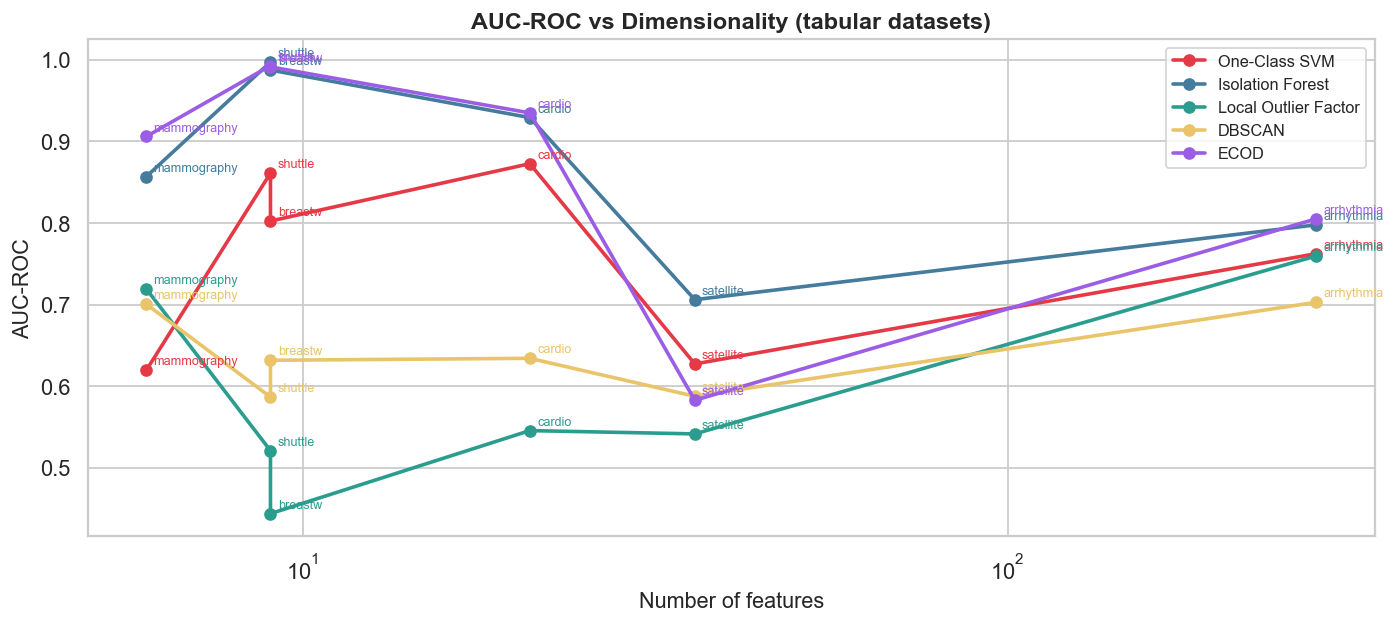

In [4]:
tabular = flat[flat['type'] == 'tabular'].copy()

fig, ax = plt.subplots(figsize=(11, 5))
for algo, color in DETECTOR_COLORS.items():
    sub = tabular[tabular['algorithm'] == algo].sort_values('n_features')
    ax.plot(sub['n_features'], sub[METRIC], marker='o', label=algo, color=color, lw=2)
    for _, row in sub.iterrows():
        ax.annotate(row['dataset'], (row['n_features'], row[METRIC]), xytext=(4, 3), textcoords='offset points', fontsize=7, color=color)

ax.set_xlabel('Number of features', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('AUC-ROC vs Dimensionality (tabular datasets)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xscale('log')
plt.tight_layout()
plt.show()


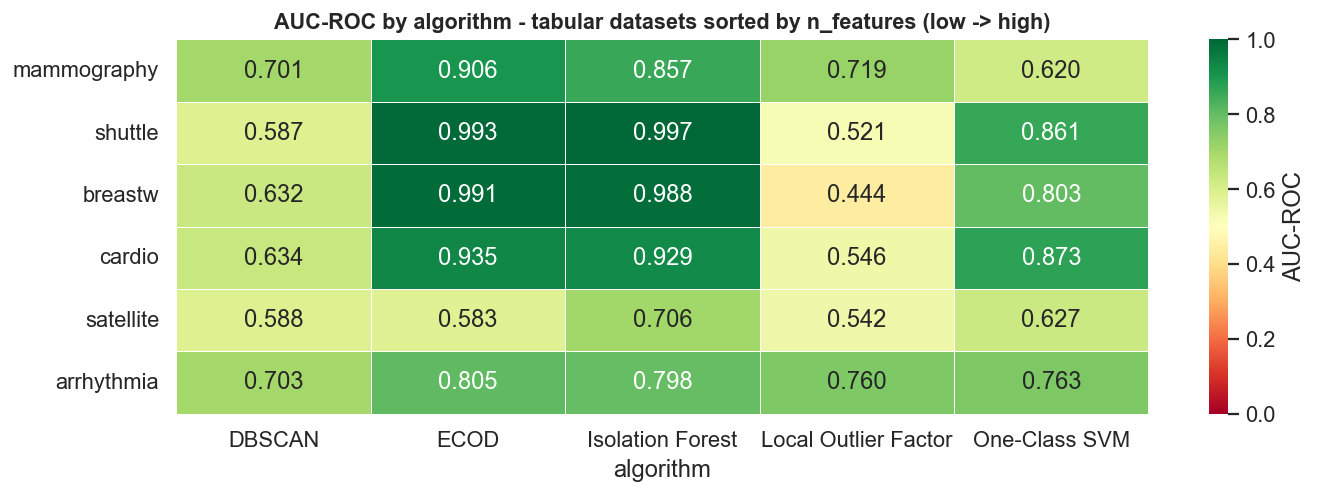

In [5]:
tabular_order = dataset_meta[dataset_meta['type']=='tabular'].sort_values('n_features').index.tolist()
pivot = flat[flat['type']=='tabular'].pivot(index='dataset', columns='algorithm', values=METRIC)
pivot = pivot.reindex(tabular_order)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.4, cbar_kws={'label': 'AUC-ROC'}, ax=ax)
ax.set_title('AUC-ROC by algorithm - tabular datasets sorted by n_features (low -> high)', fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Observations:

LOF and DBSCAN both collapse at high dimensionality - arrhythmia (274 features) is the clearest failure case for density-based methods.

Isolation Forest remains competitive across the full range.

Below baout 20 features all algorithms are somewhere comparable.

## Sample Size Effect

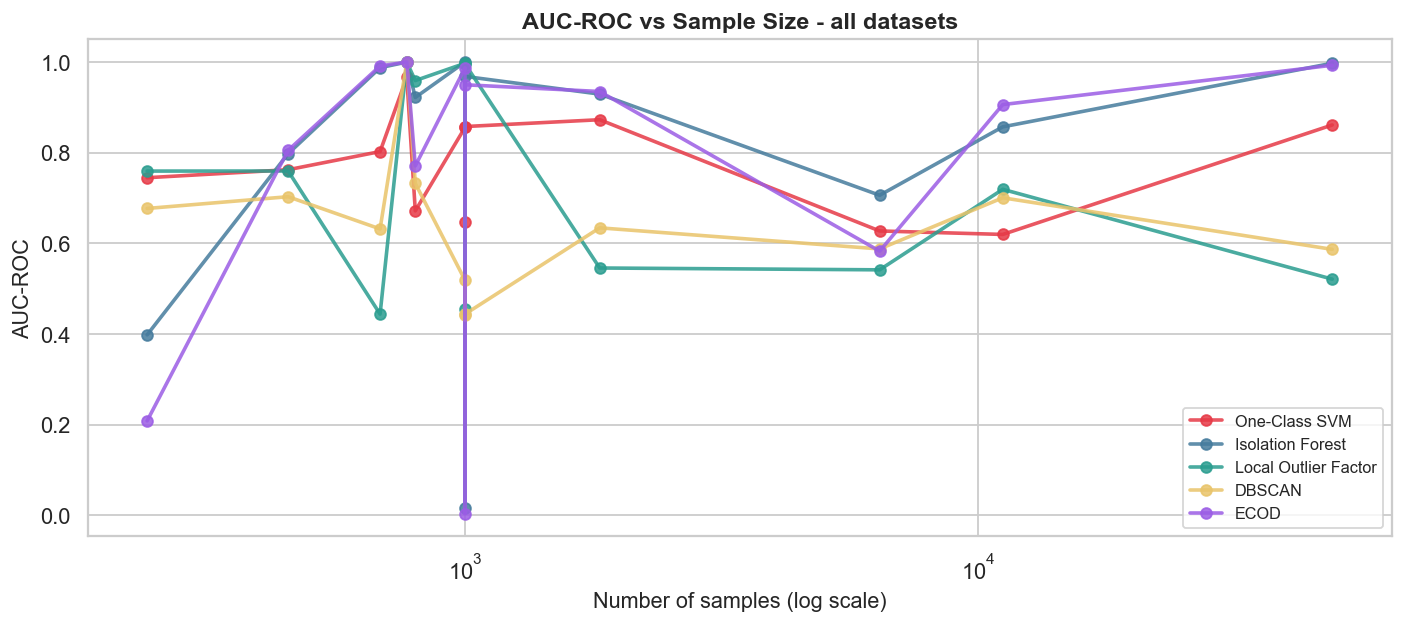

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for algo, color in DETECTOR_COLORS.items():
    sub = flat[flat['algorithm'] == algo].sort_values('n_samples')
    ax.plot(sub['n_samples'], sub[METRIC], marker='o', label=algo, color=color, lw=2, alpha=0.85)

ax.set_xlabel('Number of samples (log scale)', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_xscale('log')
ax.set_title('AUC-ROC vs Sample Size - all datasets', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Observations:

No strong universal trend - sample size alone does not predict failure. The smallest dataset (sipu_flame, 240 samples) causes problems mainly for DBSCAN which needs dense neighbourhoods. Isolation Forest and OC-SVM are basically unaffected by n_samples.

## Local vs Global Outlier Structure

Geometric datasets with ring/zigzag structure contain local outliers


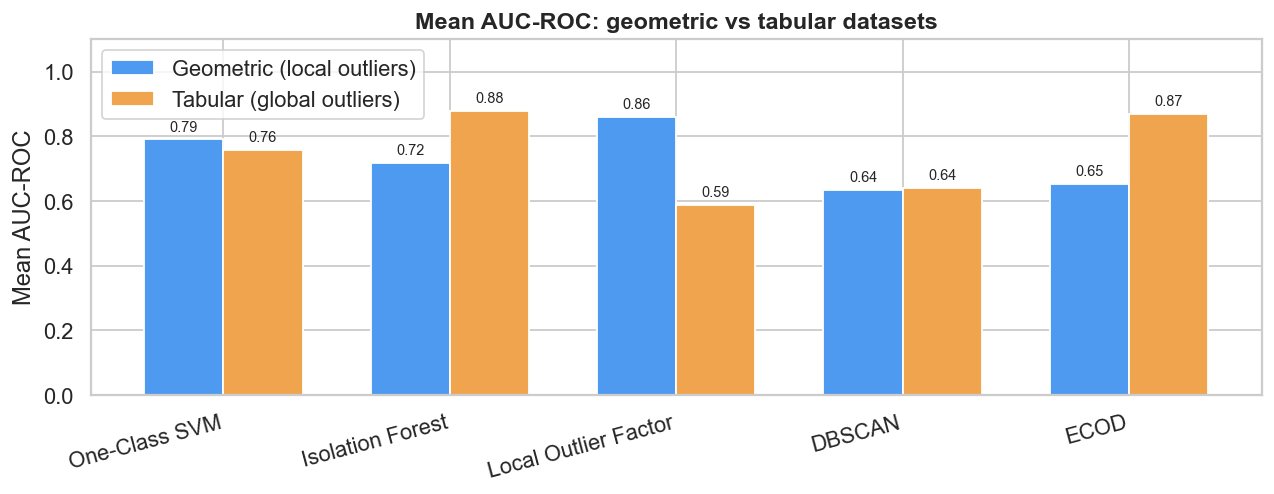

In [8]:
geo_datasets = ['graves_ring_outliers', 'graves_zigzag_outliers', 'fcps_target', 'sipu_flame', 'wut_x2', 'graves_fuzzyx']
tab_datasets = [d for d in all_results if d not in geo_datasets]

geo = flat[flat['dataset'].isin(geo_datasets)]
tab = flat[flat['dataset'].isin(tab_datasets)]

geo_mean = geo.groupby('algorithm')[METRIC].mean()
tab_mean = tab.groupby('algorithm')[METRIC].mean()
comparison = pd.DataFrame({'Geometric (local)': geo_mean, 'Tabular (global)':  tab_mean}).reindex(ALGOS)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(ALGOS))
w = 0.35
bars1 = ax.bar(x - w/2, comparison['Geometric (local)'], w, label='Geometric (local outliers)', color='#4e9af1')
bars2 = ax.bar(x + w/2, comparison['Tabular (global)'],  w, label='Tabular (global outliers)',  color='#f1a44e')
ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(ALGOS, rotation=15, ha='right')
ax.set_ylabel('Mean AUC-ROC')
ax.set_title('Mean AUC-ROC: geometric vs tabular datasets', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()


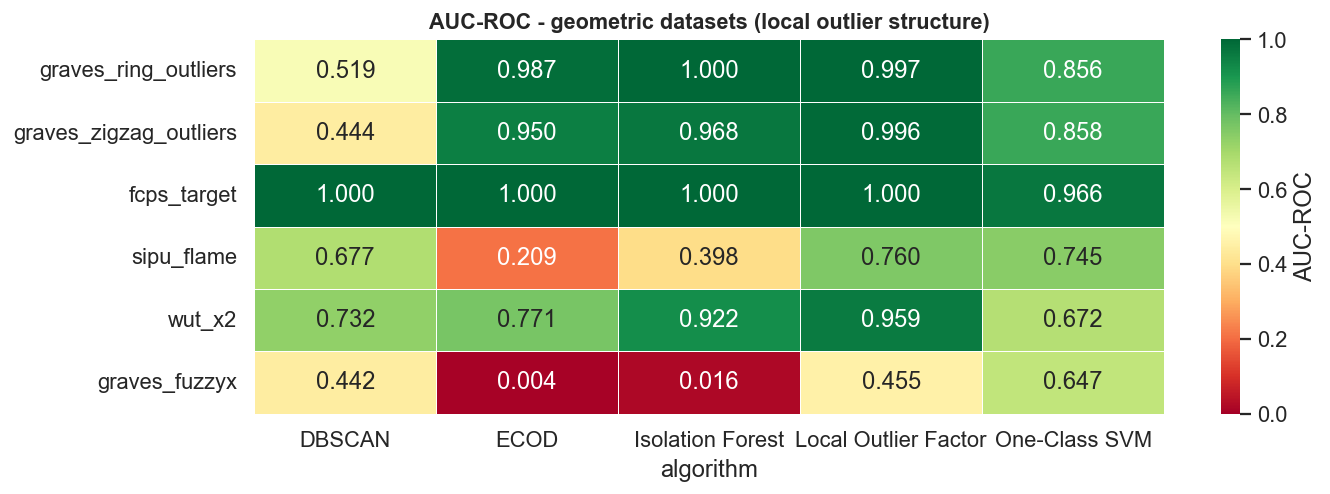

In [12]:
geo_order = geo_datasets
pivot_geo = flat[flat['dataset'].isin(geo_datasets)].pivot(index='dataset', columns='algorithm', values=METRIC).reindex(geo_order)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot_geo, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.4, cbar_kws={'label': 'AUC-ROC'}, ax=ax)
ax.set_title('AUC-ROC - geometric datasets (local outlier structure)', fontsize=12, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Observations:

Global methods struggle on geometric datasets. ECOD and Isolation Forest perform well on tabular data but drop on local-outlier structure. LOF and DBSCAN have the advantage on graves_ring and graves_zigzag, but still fail on graves_fuzzyx where no algorithm succeeds regardless of structure.

## Failure Case Summary

assume failure: AUC-ROC < 0.6 

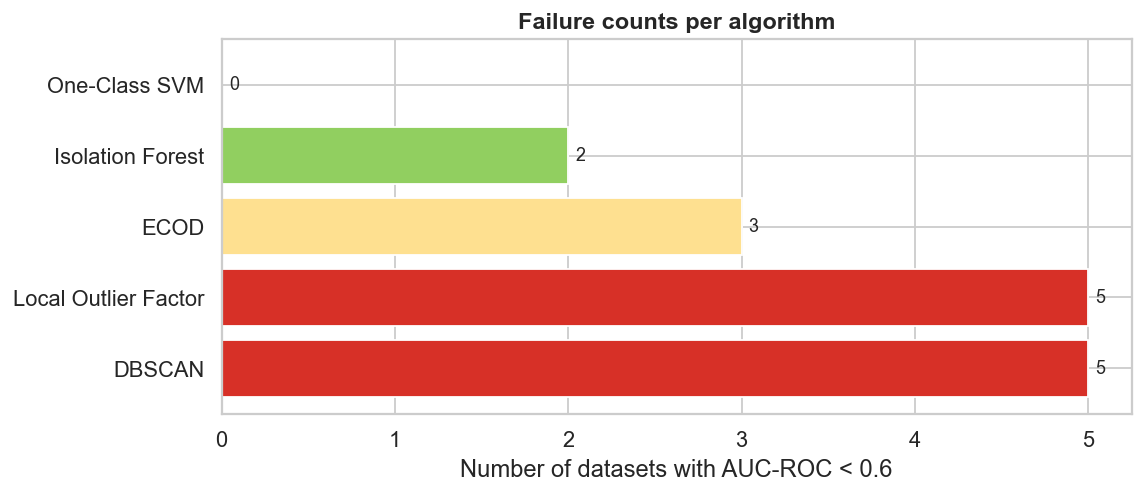

algorithm
DBSCAN                  5
Local Outlier Factor    5
ECOD                    3
Isolation Forest        2
One-Class SVM           0
Name: failure count (AUC-ROC < 0.6), dtype: int64


In [10]:
flat['failed'] = flat[METRIC] < 0.6

failure_counts = (flat.groupby('algorithm')['failed'].sum().sort_values(ascending=False).rename('failure count (AUC-ROC < 0.6)'))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d73027' if v > 4 else '#fee090' if v > 2 else '#91cf60' for v in failure_counts]
bars = ax.barh(failure_counts.index, failure_counts.values, color=colors, edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Number of datasets with AUC-ROC < 0.6')
ax.set_title('Failure counts per algorithm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(failure_counts)


Observations:

DBSCAN and LOF each fail on 5 out of 12 datasets (AUC-ROC < 0.6), making them the least reliable. OC-SVM has zero failures - but this reflects tuned results, with a bad kernel it would probably rank last. Isolation Forest is the most robust with only 2 failures, both on graves_fuzzyx and sipu_flame where the outlier structure is genuinely ambiguous.